In [1]:
import pandas as pd
from datetime import date
from src.features import *

In [2]:
order_level = pd.read_parquet("data/processed/order_level.parquet")

In [3]:
order_level.head()

,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_invalid_timestamps,review_score,total_price,total_freight,n_items,n_unique_products,n_unique_sellers,total_payment_value,n_payment_installments,n_payment_methods
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,RJ,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,False,5.0,58.90,13.29,1,1,1,72.19,2.0,1.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,SP,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,False,4.0,239.90,19.93,1,1,1,259.83,3.0,1.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,MG,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,False,5.0,199.00,17.87,1,1,1,216.87,5.0,1.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,SP,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,False,4.0,12.99,12.79,1,1,1,25.78,2.0,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,SP,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,False,5.0,199.90,18.14,1,1,1,218.04,3.0,1.0


In [4]:
order_level.isna().sum()

order_id                            0
customer_id                         0
customer_unique_id                  0
customer_state                      0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1009
order_delivered_customer_date    2190
order_estimated_delivery_date       0
is_invalid_timestamps               0
review_score                      749
total_price                         0
total_freight                       0
n_items                             0
n_unique_products                   0
n_unique_sellers                    0
total_payment_value                 1
n_payment_installments              1
n_payment_methods                   1
dtype: int64

In [5]:
order_level = add_delivery_feature(order_level)

In [6]:
order_level.head()

,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,n_unique_products,n_unique_sellers,total_payment_value,n_payment_installments,n_payment_methods,is_delivered,delivery_time,estimated_delivery_time,delivery_delay,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,RJ,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,...,1,1,72.19,2.0,1.0,True,7.0,15,-9.0,False
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,SP,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,...,1,1,259.83,3.0,1.0,True,16.0,18,-3.0,False
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,MG,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,...,1,1,216.87,5.0,1.0,True,7.0,21,-14.0,False
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,SP,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,...,1,1,25.78,2.0,1.0,True,6.0,11,-6.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,SP,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,...,1,1,218.04,3.0,1.0,True,25.0,40,-16.0,False


In [7]:
invalid_delivered = (order_level['is_delivered'] & order_level['is_invalid_timestamps']).sum()
print(invalid_delivered)

1373


1373 orders have invalid timestamp but still delivered to customers.

In [8]:
n_delivered = order_level['is_delivered'].sum()
n_late = order_level['is_late'].sum()
print(f'Delivered: {n_delivered} \n Late: {n_late} ({n_late / n_delivered * 100:.1f}%)')

Delivered: 96476 
 Late: 6535 (6.8%)


Total 96476 orders delivered, 6535 orders were late (6.8%)

Choosing 2018-09-05 as reference date

In [9]:
rfm = compute_rfm(order_level)

Removed 467 orders which have canceled/unavailable status out of rfm computation
Computed rfm for 94983 customers (customer_unique_id), reference date: 2018-09-04 09:06:57


In [10]:
rfm.sort_values(by=["recency", "frequency", "monetary"], ascending=[True, False, False])

,customer_unique_id,recency,frequency,monetary
94648,ff22e30958c13ffe219db7d711e8f564,1,2,332.92
34432,5c58de6fb80e93396e2f35642666b693,5,1,510.96
4662,0c6d7218d5f3fa14514fd29865269993,5,1,178.25
1534,0421e7a23f21e5d54efed456aedbc513,5,1,119.42
67207,b4dcade04bc548b7e3b0243c801f8c26,5,1,106.95
...,...,...,...,...
36463,61db744d2f835035a5625b59350c6b63,700,1,53.73
50299,87776adb449c551e74c13fc34f036105,700,1,40.95
17673,2f64e403852e6893ae37485d5fcacdaf,700,1,39.09
48745,830d5b7aaa3b6f1e9ad63703bec97d23,718,1,0.00


In [11]:
rfm.describe()

,recency,frequency,monetary
count,94983.000000,94983.000000,94983.000000
mean,243.433077,1.033859,165.695145
std,152.983982,0.210811,226.747872
min,1.000000,1.000000,0.000000
25%,119.000000,1.000000,63.100000
50%,224.000000,1.000000,107.900000
75%,352.000000,1.000000,182.945000
max,729.000000,16.000000,13664.080000


In [12]:
import numpy as np
rfm["monetary_log"] = np.log1p(rfm["monetary"])

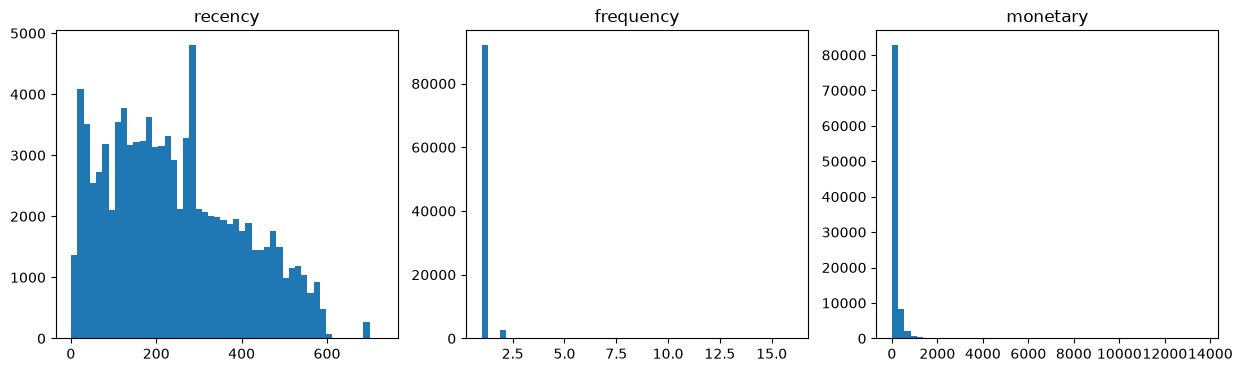

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["recency", "frequency", "monetary"]):
    ax.hist(rfm[col], bins=50)
    ax.set_title(col)
plt.show()

### Recency
There's a blank space between 600-650. This is because of the dataset
### Frequency
Nearly all the customer = 1 => cannot use this to divide customer because 90% of the customers are the same.
Retension is very low, almost the customers are one-time-buyer
### Monetary
Right-skewed. Need to be log-transformed

<Axes: xlabel='order_purchase_timestamp'>

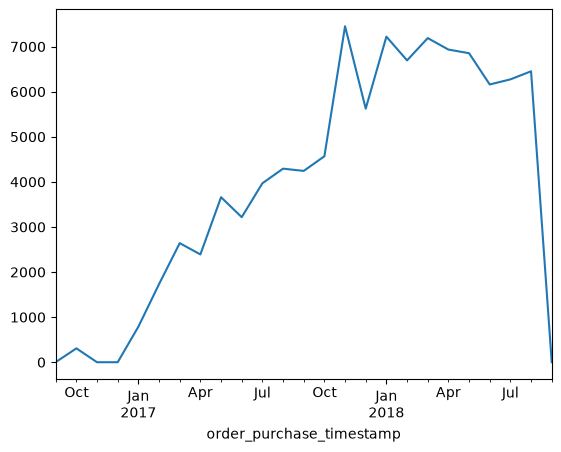

In [14]:
order_level.set_index("order_purchase_timestamp").resample("ME").size().plot()

Finding lastest purchase date:

In [15]:
print(order_level["order_purchase_timestamp"].max())

2018-09-03 09:06:57


Date numbers which have data in 4 last months to check which one is lack of days

In [16]:
order_level["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index().tail(4)

order_purchase_timestamp
2018-06    6160
2018-07    6273
2018-08    6452
2018-09       1
Freq: M, Name: count, dtype: int64

The chart shows continuous growth from 10/2016 to around mid-2018, stabilizing at around 6,000–7,000 orders/month from early 2018. Checking the maximum `order_purchase_timestamp` yields 2018-09-03, and the monthly order volume indicates that September 2018 contains only 1 order — confirming that this is truncated data due to collection limits, rather than an actual business decline. August 2018 (6,452 orders) remains within the normal trend and is unaffected. Therefore, when analyzing time-series trends, records from September 2018 should be removed (retaining data up through the end of August 2018). For RFM analysis, no records need to be removed — recency is calculated relatively among customers, so it is not impacted by an incomplete final month.

<Axes: xlabel='order_purchase_timestamp'>

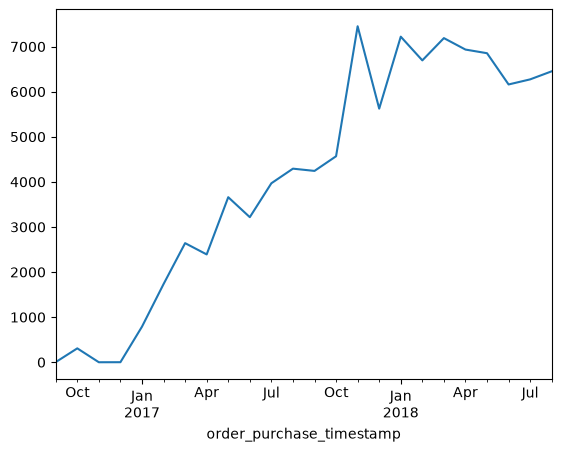

In [17]:
last_complete_month = order_level["order_purchase_timestamp"].max().to_period("M") - 1
order_level_trend = order_level[
    order_level["order_purchase_timestamp"].dt.to_period("M") <= last_complete_month
]

order_level_trend.set_index("order_purchase_timestamp").resample("ME").size().plot()

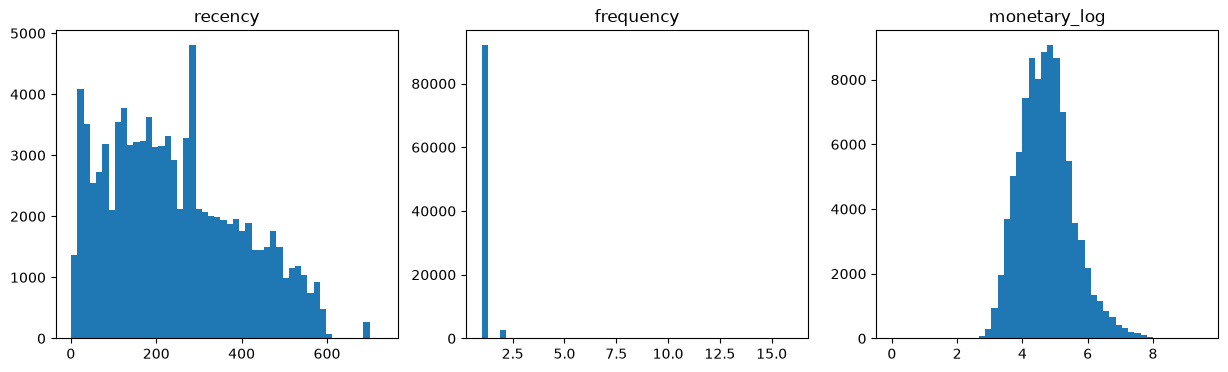

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["recency", "frequency", "monetary_log"]):
    ax.hist(rfm[col], bins=50)
    ax.set_title(col)
plt.show()

### Monetary_log
After log transformed, the distribution changed into Gaussian Distribution
### Compute frequency value percentage:

In [19]:
rfm["frequency"].value_counts(normalize=True).sort_index() * 100

frequency
1     96.960509
2      2.791026
3      0.197930
4      0.030532
5      0.009475
6      0.005264
7      0.003158
9      0.001053
16     0.001053
Name: proportion, dtype: float64

In [20]:
rfm = add_rfm_scores(rfm)

rfm_segment
New Customers       36752
Hibernating         22970
Need Attention      18386
Cannot Lose Them    13988
Loyal Customers      1723
At Risk              1035
Champions             129
Name: count, dtype: int64


In [21]:
segment_summary = (
    rfm.groupby("rfm_segment")
    .agg(
        n_customers=("customer_unique_id", "count"),
        total_revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean"),
    )
    .assign(pct_customers=lambda x: x["n_customers"] / x["n_customers"].sum() * 100)
    .assign(pct_revenue=lambda x: x["total_revenue"] / x["total_revenue"].sum() * 100)
    .sort_values("total_revenue", ascending=False)
)
print(segment_summary)

                  n_customers  total_revenue  avg_monetary  pct_customers  \
rfm_segment                                                                 
New Customers           36752     6054809.99    164.747769      38.693240   
Cannot Lose Them        13988     4324287.50    309.142658      14.726846   
Need Attention          18386     2796760.59    152.113597      19.357148   
Hibernating             22970     1671978.91     72.789678      24.183275   
Loyal Customers          1723      514397.74    298.547731       1.814009   
At Risk                  1035      305858.35    295.515314       1.089669   
Champions                 129       70128.87    543.634651       0.135814   

                  pct_revenue  
rfm_segment                    
New Customers       38.472008  
Cannot Lose Them    27.476341  
Need Attention      17.770499  
Hibernating         10.623684  
Loyal Customers      3.268462  
At Risk              1.943411  
Champions            0.445596  


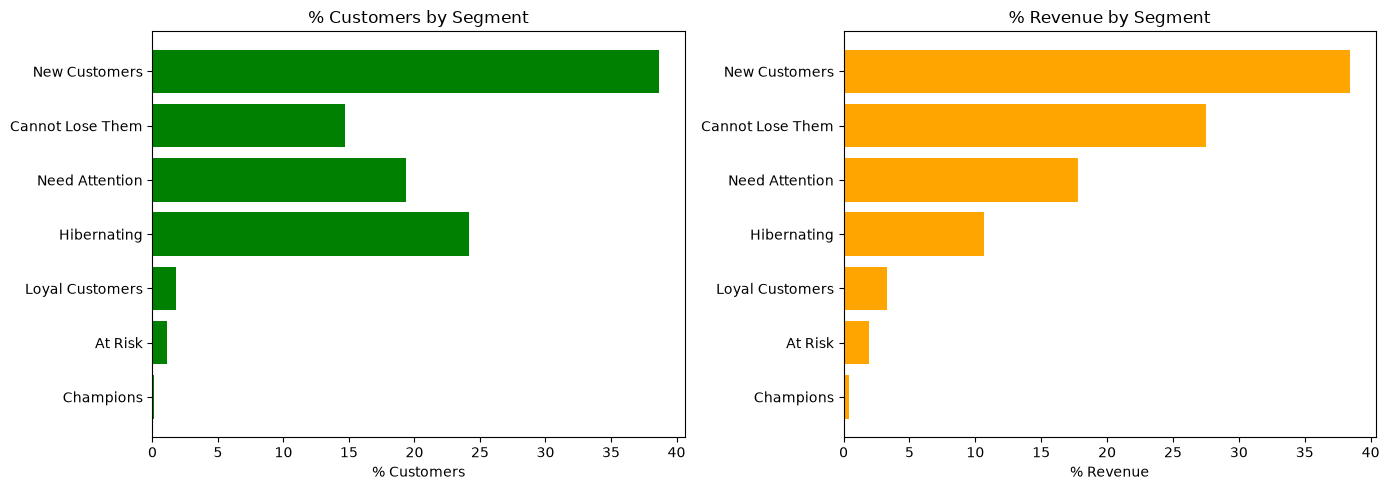

In [27]:
import matplotlib.pyplot as plt

segment_summary = segment_summary.sort_values("total_revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(segment_summary.index, segment_summary["pct_customers"], color="green")
axes[0].set_title("% Customers by Segment")
axes[0].invert_yaxis()
axes[0].set_xlabel("% Customers")

axes[1].barh(segment_summary.index, segment_summary["pct_revenue"], color="orange")
axes[1].set_title("% Revenue by Segment")
axes[1].invert_yaxis()
axes[1].set_xlabel("% Revenue")

plt.tight_layout()
plt.show()

**1. "Cannot Lose Them" is the most important finding of this analysis**
This group only accounts for **14.7% of customers but contributes 27.5% of revenue** - a contribution rate nearly double the quantity proportion. These are customers who used to spend very high amounts (average 309 BRL/customer, second highest after Champions) but have not returned for a long time (low recency). This group is the highest priority for a win-back campaign — the cost of retaining this group is much lower than attracting new customers of equal value.

**2. "New Customers" contribute the largest revenue in total, but the average value is low**
Accounts for 38.7% of customers and 38.5% of revenue (proportionate ratio) — but `avg_monetary` is only 164.7 BRL, much lower than Cannot Lose Them or Champions. This is a new group, the value of each customer is not high - an opportunity to implement a second purchase incentive program (if part of this group can be converted to "Loyal", the average value can increase significantly).

**3. Champions are extremely small but have an exceptionally high average value**
Only 129 customers (0.14%) but `avg_monetary` = 543.6 BRL — ~3.3 times more than New Customers. Although the total revenue contribution is only 0.45% (due to the small number), this is a group that should have its own VIP care program to maximize lifetime value and encourage referrals.

**4. Hibernating accounts for the majority (24.2%) but contributes the lowest revenue by proportion (10.6%).**
`avg_monetary` is only 72.8 BRL — the lowest of the bunch. This is a one-time customer, low order value, has been inactive for a long time — re-engagement priority should be lower than Cannot Lose Them, because the expected ROI is lower.

### Proposed comprehensive actions (in order of priority)
1. **Cannot Lose Them**: Personalized emails/vouchers target high order value — #1 priority because of highest revenue/customer ratio in large groups.
2. **New Customers**: Second order incentive program (discount on next purchase) — convert to Loyal/Champions.
3. **Champions**: Private VIP/loyalty program, referral incentive.
4. **Hibernating**: Low cost re-engagement (automatic emails), does not invest a lot of resources.